# Изучение рынка заведений общественного питания Москвы

- Автор: Алёна Опольская
- Дата: 30.01.26

### Цели и задачи проекта

<font color='#777778'>Цель исследовательского анализа - рассмотреть рынок общественного питания Москвы и помочь инвесторам из фонда Shut Up and Take My Money сделать обоснованный выбор фомата и места заведения, которое они хотят открыть.  </font>

### Описание данных

<font color='#777778'>Датасет представлен данными о заведениях общественного питания Москвы, на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.

Датасет содержит следующие данные:
- `name` — название заведения;
- `address` — адрес заведения;  
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения; 
- `hours` — информация о днях и часах работы; 
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0); 
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (1 = сетевое); 
- `seats` — количество посадочных мест; 
- `price` — категория цен в заведении;
- `avg_bill` — средняя стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, если avg_bill начинается с подстроки «Средний счёт»;
- `middle_coffee_cup` — число с оценкой среднего чека, если avg_bill начинается с подстроки «Цена чашки капучино»;
</font>

### Содержимое проекта

<font color='#777778'>
1. Загрузка данных и знакомство с ними <br>
2. Предобработка данных <br>
3. Исследовательский данных <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1 Категории заведений <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2 Административные районы <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3 Сетевые/несетевые заведения <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.4 Посадочне места <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.5 Рейтинг заведений <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.6 Зависимость рейтинга заведений <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7 ТОП-15 сетей <br>
&nbsp;&nbsp;&nbsp;&nbsp;3.8 Средний чек заведений <br>
4. Итоговый вывод и рекомендации <br>

---

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
!pip install phik

     |████████████████████████████████| 677 kB 1.5 MB/s eta 0:00:01


In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

In [3]:
# Выгрузим данные
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомьтесь с данными и изучите общую информацию о них.

In [4]:
# Выведем информацию о rest_info и первые 5 строк 
rest_info.info()
rest_info.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выведем информацию о rest_price и первые 5 строк 
rest_price.info()
rest_price.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Данные о заведениях представлены 8406 строками и 9 столбцами, что соответствует изначальному описанию данных. На что нужно обратить внимание:
- есть пропуски в столбцах hours и seats;
- размерность данных в столбцах rating и chain можно оптимизировать, т. к. максимальные значения в них 5 и 1 соответственно;
- столбец seats представлен вещественным типом, хотя количество посадочных мест может быть только целым. Можно будет привести его к типу Int64, учитывая что в данных есть пропуски.

Данные о среднем чеке представлены 4058 строками и 5 столбцами, что соответствует изначальному описанию данных. На что нужно обратить внимание:

- есть пропуски во всех столбцах, кроме id (помним, что middle_avg_bill и middle_coffee_cup указываются только при определенных условиях в avg_bill, поэтому пропуски в них могут быть вполне логичными).
   
В обоих датасетах есть столбец id, по которому будем обьединять данные. 


### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [6]:
# Объединим два датасета в один
df = pd.merge(rest_info, rest_price, on='id', how='left')

In [7]:
# Выведем информацию о новом датасете и первые 5 строк 
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


В объединенном датасете 8406 строк, как и в изначальном основном (rest_info), значит мы не потряли информацию о заведениях при объединении. 

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [8]:
# Оптимизируем тип данных столбцов rating и chain 
df['rating'] = pd.to_numeric(df['rating'], downcast='float')
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [9]:
# Поменяем тип данных для столбца seats на целочисленный (с сохранением пропусков)
df['seats'] = df['seats'].astype('Int64')

In [10]:
# Проверим типы данных в датасете
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                  Int64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

При знакомстве с данными мы обнаружили пропуски в следующих столбцах: hours, seats, price, avg_bill, middle_avg_bill и middle_coffee_cup. Сначала посчитаем пропуски в hours, seats, price.

In [11]:
# Узнаем абсолютное и относительное количество пропусков в столбце hours
no_hours_count = df['hours'].isna().sum()
no_hours_share = no_hours_count / df.shape[0]

print(f'Количество пропусков hours: {no_hours_count}')
print(f'Доля пропусков hours: {no_hours_share:.2%}')

Количество пропусков hours: 536
Доля пропусков hours: 6.38%


Доля пропусков в столбце с графиком работы заведений составляет около 6,4%. Это небольшая доля пропусков, но удалять такие пропуски мы не будем, оставим как есть - скорее всего эта информация просто не была указана заведением в Яндекс Картах или Яндекс Бизнес. 

In [12]:
# Узнаем абсолютное и относительное количество пропусков в столбце seats
no_seats_count = df['seats'].isna().sum()
no_seats_share = no_seats_count / df.shape[0]

print(f'Количество пропусков seats: {no_seats_count}')
print(f'Доля пропусков seats: {no_seats_share:.2%}')

Количество пропусков seats: 3611
Доля пропусков seats: 42.96%


Доля пропусков в столбце с количеством посадочных мест составляет около 43%. Это очень большая доля отсутствующих данных. Можно было бы заменить их на среднее количество посадочных мест по категории заведения, но ведь есть вероятность, что заведение может работать только на вынос (например, в формате 'coffee to go') или располагаться внутри какого-то здания, как корнер, что не предполагает наличие посадочных мест для гостей. При этом на 0 тоже заменить нельзя - возможно для некоторых заведений все же просто не указаны данные, а на самом деле места для посадки существуют. В таком случае мы можем исказить данные, поэтому принято решение не трогать пропуски.

In [13]:
# Узнаем абсолютное и относительное количество пропусков в столбце price
no_price_count = df['price'].isna().sum()
no_price_share = no_price_count / df.shape[0]

print(f'Количество пропусков price: {no_price_count}')
print(f'Доля пропусков price: {no_price_share:.2%}')

Количество пропусков price: 5091
Доля пропусков price: 60.56%


Очень высокая доля пропусков в столбце с категорией цен. Скорее всего это связано с тем, что информация по ценам не была предоставлена при заполнении "карточки заведения" на сервисах, откуда собирался датасет. Это столбец типа Object и чтобы далее было удобнее работать с категориями, можем заменить пропуски на unknown. По сути мы не искажаем данные, а просто выделяем новую категорию для заведений, где не знаем категорию цен. 

In [14]:
# Заменим пропуски в столбце price на unknown
df['price'] = df['price'].fillna('unknown')
# Посчитаем пропуски для проверки
df['price'].isna().sum()

0

Пропуски в столбце avg_bill можно не заменять, т к это вспомогательный столбец для определения middle_avg_bill и middle_coffee_cup (для дальнейшего анализа средних цен мы скорее будем использовать их, а не сам avg_bill). Соответственно оставляем пропуски и в этих 2 столбцах - они вполне логичны при отсутствии информации в avg_bill.
Однако лучше проверим значения в avg_bill, чтобы убедиться, что в столбце есть только пропуск или корректные подстроки (Цена чашки капучино/Средний счёт/Цена бокала пива).

In [15]:
# Посчитаем количество "неверных" значений в столбце avg_bill
mask = (df['avg_bill'].notna() & (df['avg_bill'].str.startswith(('Средний счёт', 'Цена чашки капучино', 'Цена бокала пива'))== False))
mask.sum()

0

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [16]:
# Приведем названия заведений к одному регистру, уберем лишние пробелы в начале и конце,
# а также проверим на знаки препинания (могут содержаться в названии и где-то быть указаны, а где-то нет)
df['new_name'] = df['name'].str.lower().str.strip().str.replace('!', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '', regex=False)
# Проверим на дубликаты (смотрим по названию + адресу, т к заведение одного названия может быть по разным адресам, если оно сетевое)
duplicates = df[df.duplicated(subset=['new_name', 'address'], keep=False)]
# Посчитаем количество дубликатов
duplicates_count = duplicates.shape[0]

print(f'Количество строк дубликатов: {duplicates_count}')
duplicates

Количество строк дубликатов: 8


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,new_name
599,be007021c2a44e2f9488f7b3174d1a2b,В парке вкуснее!,кафе,"Москва, Северный административный округ, район...",Северный административный округ,"ежедневно, 10:00–21:00",2.2,0,<NA>,unknown,NaN,NaN,NaN,в парке вкуснее
600,82ea6220bb4e4ffe83bfdf1dd7b4d556,В парке вкуснее,кофейня,"Москва, Северный административный округ, район...",Северный административный округ,"ежедневно, 10:00–21:00",2.2,1,<NA>,unknown,NaN,NaN,NaN,в парке вкуснее
1430,62608690e9cc464fbcd980cfd552e334,More poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,unknown,NaN,NaN,NaN,more poke
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,unknown,NaN,NaN,NaN,more poke
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня Клешни и Хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,unknown,NaN,NaN,NaN,раковарня клешни и хвосты
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни и хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,unknown,NaN,NaN,NaN,раковарня клешни и хвосты
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб да Выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,unknown,NaN,NaN,NaN,хлеб да выпечка
3109,d3116844e4e048f99614eb30be3214e0,Хлеб да выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,unknown,NaN,NaN,NaN,хлеб да выпечка


Мы вывели все строки-дубликаты и видим, что их всего 8 - это менее 1 % всего датасета.
При этом:
- некоторые дубликаты имеют разную категорию. Это может быть связано с тем, что данные брались из 2 сервисов, а возможно формат заведения подходит под обе категории;
- у некоторых дубликатов указано разное время работы.

Например, раковарня может работать в формате ресторана до 00:00, а потом закрывать кухню и работать в формате бара дольше, как это указано в дубликате с категорией "бар, паб".

Учитывая то, что есть различия, природу которых мы точно не знаем, и при этом доля дубликатов очень мала, мы можем их не удалять. Это позволит сохранить заведения при анализе по категориям, и при этом существенно не повлияет на результаты анализа по другим параметрам.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [17]:
# Создадим столбец и выведем первые 5 строк для проверки
df['is_24_7'] = (df['hours'].str.contains('ежедневно', na=False) & df['hours'].str.contains('круглосуточно', na=False))
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,new_name,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,unknown,NaN,NaN,NaN,wowфли,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,четыре комнаты,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN,хазри,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,unknown,Цена чашки капучино:155–185 ₽,NaN,170.0,dormouse coffee shop,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN,иль марко,False


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

In [18]:
# Выведем информацию о датасете после предобработки данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   Int64  
 9   price              8406 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  new_name           8406 non-null   object 
 14  is_24_7            8406 non-null   bool   
dtypes: Int64(1), bool(1), float32(1), float64(2), int8(1), object(9)
memory 

В ходе предобработки данных были выполнены следующие действия:
- работа с типами данных: оптимизирована размерность данных в столбцах rating и chain, т. к. максимальные значения в них 5 и 1 соответственно; столбец seats приведен к типу Int64 (количество посадочных мест - целое число, при этом учли, что в данных есть пропуски)
- работа с пропусками: были посчитаны пропуски в столбцах hours (6,38%), seats(42,96%) и price(60,56%). Пропуски не удалялись, чтобы не искажать данные (подробнее о каждом столбце описано выше, в промежуточных комментариях). В столбце price (тип object) пропуски заменили на unknown для удобства в дальнейшей работе со столбцом. В столбцах middle_avg_bill и middle_coffee_cup пропуски вполне логичны, учитывая, что они заполняются по определенному условию в столбце avg_bill (пропуски в нем, также, не удаляли)
- работа с дубликатами: выполнили нормализацию наименования заведений (новый столбец new_name) и нашли 8 строк дубликатов (4 заведения). При этом в некоторых столбцах одного заведения (например время работы, категория) были различия, а доля дубликатов менее 1%, в связи с чем принято решение не удалять дубликаты
- создали новый столбец is_24_7 с обозначением того, что заведение работает ежедневно и круглосуточно.

Обработанный датасет содержит 8406 строк и 15 столбцов. 

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [19]:
# Считаем количество заведений в каждой категории
category_count = df['category'].value_counts()
category_share = round(category_count / category_count.sum() * 100, 1)
category_info = pd.DataFrame({
    'Количество объектов':category_count,
    'Доля в %':category_share
})

print(f'Общее количество заведений: {category_count.sum()}')
print(category_info)


Общее количество заведений: 8406
                 Количество объектов  Доля в %
кафе                            2378      28.3
ресторан                        2043      24.3
кофейня                         1413      16.8
бар,паб                          765       9.1
пиццерия                         633       7.5
быстрое питание                  603       7.2
столовая                         315       3.7
булочная                         256       3.0


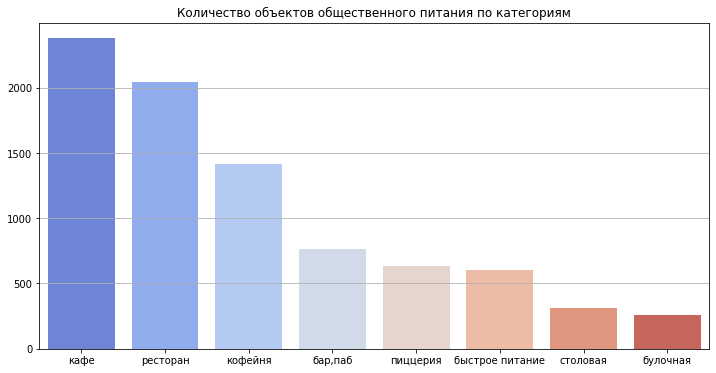

In [20]:
# Группируем данные и считаем количество заведений по категориям
df_aggcat=df.groupby('category')['id'].agg('count').reset_index().sort_values(by='id', ascending=False)
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(data=df_aggcat, x='category', y='id', palette='coolwarm')


plt.title('Количество объектов общественного питания по категориям')
plt.xlabel('')
plt.ylabel('')
plt.grid(axis='y')
plt.show()

Всего в датасете представлено 8 категорий. Топ 3 категории по количеству заведений: кафе, ресторан и кофейня, на которые в общем приходится 69,4% от всех объектов общественного питания. Наименьшее количество заведений входит в категории столовая (3,7%) и булочная (3%). 

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [21]:
# Считаем количество заведений в каждом административном районе
district_count = df['district'].value_counts()
district_share = round(district_count / district_count.sum() * 100, 1)
district_info = pd.DataFrame({
    'Количество объектов':district_count,
    'Доля в %':district_share
})

print(f'Общее количество заведений: {district_count.sum()}')
print(district_info)

Общее количество заведений: 8406
                                         Количество объектов  Доля в %
Центральный административный округ                      2242      26.7
Северный административный округ                          900      10.7
Южный административный округ                             892      10.6
Северо-Восточный административный округ                  891      10.6
Западный административный округ                          851      10.1
Восточный административный округ                         798       9.5
Юго-Восточный административный округ                     714       8.5
Юго-Западный административный округ                      709       8.4
Северо-Западный административный округ                   409       4.9


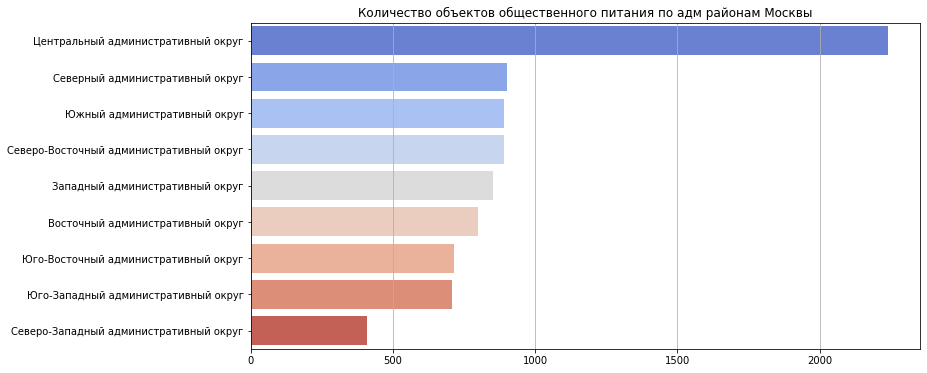

In [22]:
# Группируем данные и считаем количество заведений по категориям
df_aggdist=df.groupby('district')['id'].agg('count').reset_index().sort_values(by='id', ascending=False)
# Строим диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(data=df_aggdist, y='district', x='id', palette='coolwarm')

plt.title('Количество объектов общественного питания по адм районам Москвы')
plt.xlabel('')
plt.ylabel('')
plt.grid(axis='x')
plt.show()

Больше всего заведений сосредоточено в Центральном административном округе (около 27%). Далее около 10-11% в Северном, Южном, Сев-Восточном, Западном и Восточном округах. Меньше всего заведений из датасета расположены в Северо-Западном адм округе (около 5%). 

In [23]:
# Считаем количество заведений в каждой категории в ЦАО
cao=df[df['district'] == 'Центральный административный округ']
cao_category_count = cao['category'].value_counts()
cao_category_share = round(cao_category_count / cao_category_count.sum() * 100, 1)
cao_category_info = pd.DataFrame({
    'Количество объектов':cao_category_count,
    'Доля в %':cao_category_share
})

print(f'Общее количество заведений: {cao_category_count.sum()}')
print(cao_category_info)

Общее количество заведений: 2242
                 Количество объектов  Доля в %
ресторан                         670      29.9
кафе                             464      20.7
кофейня                          428      19.1
бар,паб                          364      16.2
пиццерия                         113       5.0
быстрое питание                   87       3.9
столовая                          66       2.9
булочная                          50       2.2


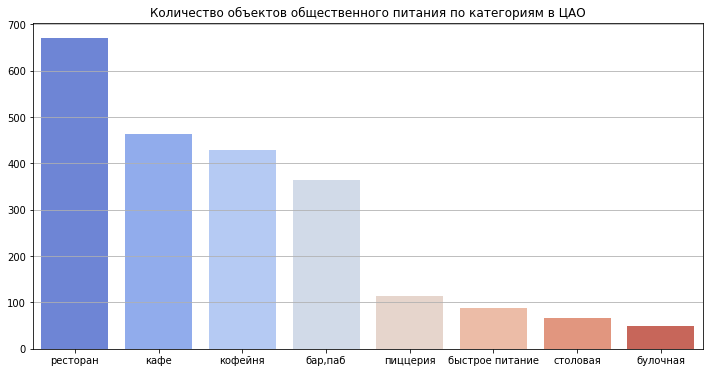

In [24]:
# Группируем данные и считаем количество заведений по категориям в ЦАО
df_aggcao=cao.groupby('category')['id'].agg('count').reset_index().sort_values(by='id', ascending=False)
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(data=df_aggcao, x='category', y='id', palette='coolwarm')


plt.title('Количество объектов общественного питания по категориям в ЦАО')
plt.xlabel('')
plt.ylabel('')
plt.grid(axis='y')
plt.show()

Всего в ЦАО представлены 2242 заведения. Почти 30% - заведения категории "ресторан". Далее (по 15-20%) составляют категории кафе, кофейня и бар/паб. Заведения остальных категорий занимают менее 10% от общего кол-ва заведений в ЦАО. 

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [25]:
# Группируем данные по признаку chain и считаем кол-во сетевых/несетевых объектов
chain_counts = df['chain'].value_counts()
chain_share = round(chain_counts / chain_counts.sum() * 100, 1)
chain_info = pd.DataFrame({
    'Количество объектов': chain_counts,
    'Доля в %': chain_share
})
print(chain_info)

   Количество объектов  Доля в %
0                 5201      61.9
1                 3205      38.1


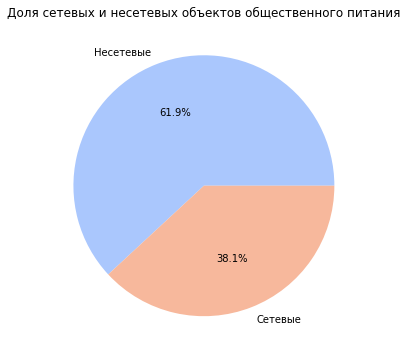

In [27]:
plt.figure(figsize=(6,6))
plt.pie(chain_info['Доля в %'], autopct='%1.1f%%', labels=['Несетевые','Сетевые'], colors=sns.color_palette('coolwarm', 2))
plt.title('Доля сетевых и несетевых объектов общественного питания')
plt.show()

Не сетевых объектов общественного питания больше, чем сетевых (62% и 38% от общего количества объектов).
Теперь рассмотрим сетевые и несетевые объекты в разрезе категорий заведений.

In [28]:
# Cтроим сводную таблицу, чтобы посмотреть кол-во сетевых/несетевых по категориям
pivot_chain_cat = pd.pivot_table(df, index='category', columns='chain', values='id', aggfunc='count')
print(pivot_chain_cat)

chain               0    1
category                  
бар,паб           596  169
булочная           99  157
быстрое питание   371  232
кафе             1599  779
кофейня           693  720
пиццерия          303  330
ресторан         1313  730
столовая          227   88


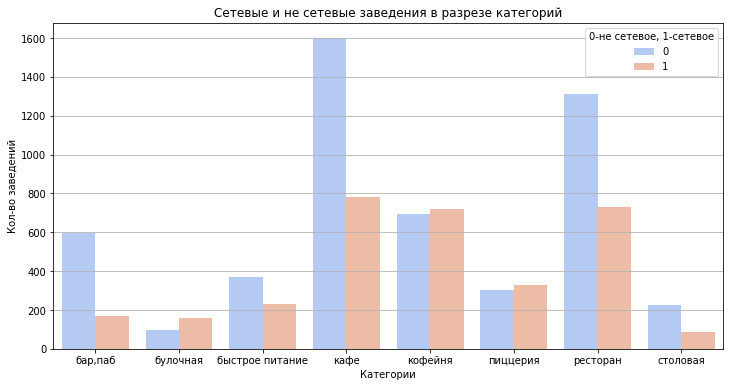

In [29]:
# Строим диаграмму
df_aggchain=df.groupby(['category', 'chain'])['id'].agg('count').reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=df_aggchain, x='category', y='id', hue='chain', palette='coolwarm')


plt.title('Сетевые и не сетевые заведения в разрезе категорий')
plt.xlabel('Категории')
plt.ylabel('Кол-во заведений')
plt.grid(axis='y')
plt.legend(title='0-не сетевое, 1-сетевое')
plt.show()

В большинстве категорий преобладает количество несетевых заведений, а именно: "бар,паб", "быстрое питание", "кафе", "ресторан", "столовая". Чаще встречаются сетевые заведения, чем не сетевые, в категории "булочная". В категориях "кофейня" и "пиццерия" соотношение примерно одинаковое, есть небольшой перевес в сторону сетевых. 

In [30]:
# Считаем количество и долю сетевых заведений с группировкой по категории
# (общее кол-во заведений в категории мы уже считали ранее - category_count)
cat_chain_count = df[df['chain'] == 1]['category'].value_counts()
cat_chain_share = round(cat_chain_count / category_count * 100, 1)
cat_chain_info = pd.DataFrame({
    'Количество сетевых заведений': cat_chain_count,
    'Доля сетевых заведений (%)': cat_chain_share
}).fillna(0).sort_values(by='Доля сетевых заведений (%)', ascending=False)
cat_chain_info = cat_chain_info.reset_index().rename(columns={'index': 'category'})

print(cat_chain_info)

          category  Количество сетевых заведений  Доля сетевых заведений (%)
0         булочная                           157                        61.3
1         пиццерия                           330                        52.1
2          кофейня                           720                        51.0
3  быстрое питание                           232                        38.5
4         ресторан                           730                        35.7
5             кафе                           779                        32.8
6         столовая                            88                        27.9
7          бар,паб                           169                        22.1


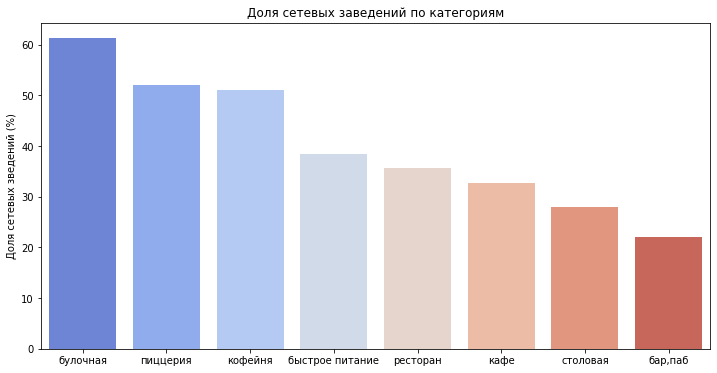

In [31]:
# Строим диаграмму
plt.figure(figsize=(12,6))
sns.barplot(data=cat_chain_info, x='category', y='Доля сетевых заведений (%)', palette='coolwarm')

plt.title('Доля сетевых заведений по категориям')
plt.xlabel('')
plt.ylabel('Доля сетевых зведений (%)')
plt.show()

В большинстве категорий доля сетевых заведений менее 40%. В категориях Пиццерия и Кофейня сетевых заведений немного больше половины (52% и 51%), а вот в категории Булочная сетевые заведения составляют 61% от общего числа заведений этой категории. Булочная - единственная категория, в которой доля сетевых заведений значительно превышает долю несетвых. 

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [32]:
# Посмотрим статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Медиана составляет 75 посадочных мест, при этом среднее значение сильно отличается от медианы (оно выше). 75% заведений имеют до 140 посадочных мест. Скорее всего в датасете есть выбросы - заведения,  для которых указано очень большое количество посадочных мест, что и искажает среднее значение. 

Минимальное значение 0 - скорее всего это заведения формата "на вынос", но возможно для них не указано количество посадочных мест. Максимальное значение 1288 посадочных мест, что также говорит о наличии выбросов в данных. 

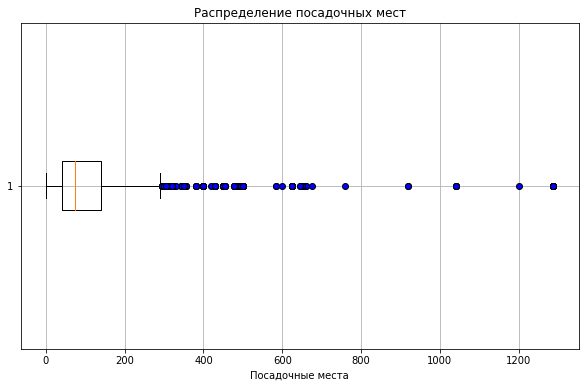

In [33]:
# Строим диаграмму размаха для посадочных мест (ящик с усами)
plt.figure(figsize=(10, 6))
plt.boxplot(df['seats'].dropna(),vert=False,flierprops=dict(markerfacecolor='b', marker='o'))

plt.title('Распределение посадочных мест')
plt.xlabel('Посадочные места')
plt.grid(True)
plt.show()


Да, рапределение данных посадочных мест не однородно и имеет выбросы. Есть заведения с очень большим количеством мест для посадки гостей. Они могут быть ошибочными, а могут быть логичны (например, большие банкетные залы для крупных мероприятий, или фудкорты), поэтому для анализа их оставим. 

Теперь посмотрим как распределяются данные в столбце seats по категориям заведений.

In [34]:
# Найдем медиану для каждой категории
median_seats = (df.groupby('category')['seats'].median().reset_index(name='seats_mediana')).sort_values(by='seats_mediana', ascending=False)
median_seats

,category,seats_mediana
6,ресторан,86.0
0,"бар,паб",82.5
4,кофейня,80.0
7,столовая,75.5
2,быстрое питание,65.0
3,кафе,60.0
5,пиццерия,55.0
1,булочная,50.0


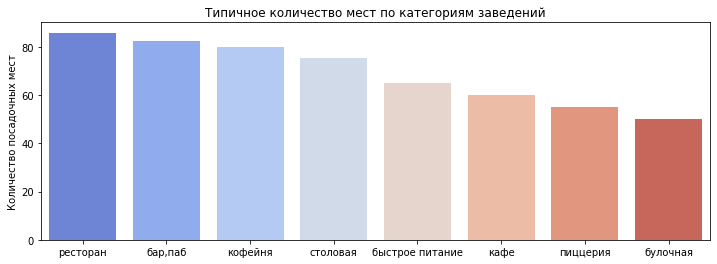

In [35]:
# Построим столбчатую диарамму
plt.figure(figsize=(12,4))
sns.barplot(data=median_seats.sort_values(by='seats_mediana', ascending=False), x='category', y='seats_mediana', palette='coolwarm')

plt.title('Типичное количество мест по категориям заведений')
plt.xlabel('')
plt.ylabel('Количество посадочных мест')
plt.show()

Ресторан, бар/паб, кофейня и столовая: в этих категориях медиана (типичное количество посадочных мест) выше. В категориях пиццерия и булочная медиана ниже, что может быть связано с более маленькой площадью заведений этих категорий, и обычно в такие заведения люди заходят "быстро перекусить" или берут еду на вынос, поэтому гости находятся в заведении не долго, в связи с чем формат не подразумевает большой зал. 

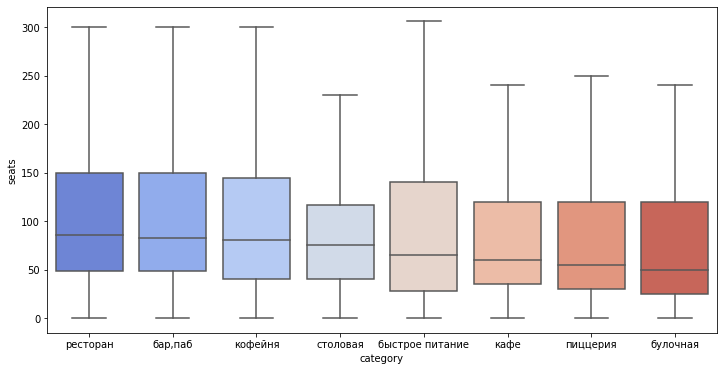

In [36]:
# Построим диаграмму размаха по категориям, уберем с визуализации отображение выбросов
order = median_seats['category']
plt.figure(figsize=(12,6))
sns.boxplot(data=df, y='seats', x='category', showfliers=False, palette='coolwarm', order=order)
plt.title('')
plt.show()

В таких категориях, как ресторан, кофейня, бар/паб и быстрое питание данные более вариативны (есть заведения и с маленьким, и с большим количеством посадочных мест). Наиболее однородное распределение у столовых.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [37]:
# Находим средний рейтинг для каждой категории
mean_rating = (df.groupby('category')['rating'].mean().reset_index(name='avg_rating'))
mean_rating

,category,avg_rating
0,"бар,паб",4.387712
1,булочная,4.268359
2,быстрое питание,4.050249
3,кафе,4.123886
4,кофейня,4.277282
5,пиццерия,4.301264
6,ресторан,4.290357
7,столовая,4.211429


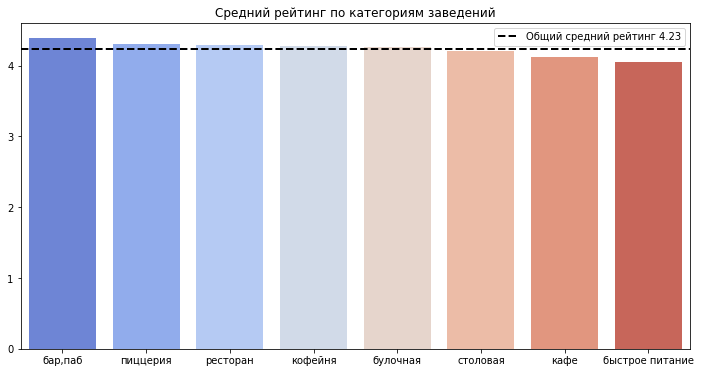

In [38]:
# Построим столбчатую диарамму
plt.figure(figsize=(12,6))
sns.barplot(data=mean_rating.sort_values(by='avg_rating', ascending=False), x='category', y='avg_rating', palette='coolwarm')
# Считаем среднее значение по среднему рейтингу
mean_rating_total = df['rating'].mean()
# Добавляем на график линию со средним значением
plt.axhline(mean_rating_total, color='black', linestyle='--', linewidth=2, label=f'Общий средний рейтинг {mean_rating_total:.2f}')

plt.title('Средний рейтинг по категориям заведений')
plt.xlabel('')
plt.ylabel('')
plt.legend()
plt.show()

Для разных типов общепита рейтинге не имеют сильного различия, средний рейтинг по всем категориям 4.23, при этом рейтинг каждой категории находится близко к усредненной линии. Минимальный средний рейтинг у категории быстрого питания (4,05), а максимальный у категории бар/паб (4,39).

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [39]:
# Вычисляем матрицу корреляций
df_corr = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']]
correlation_matrix = df_corr.phik_matrix(interval_cols=['rating', 'seats', 'chain'])
print('Корреляционная матрица:')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

Корреляционная матрица:


,rating
price,0.310534
category,0.198949
district,0.189389
is_24_7,0.160804
chain,0.119071
seats,0.000000


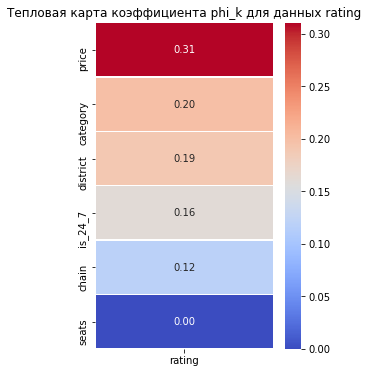

In [40]:
# Строим тепловую карту
plt.figure(figsize=(4, 6))
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Тепловая карта коэффициента phi_k для данных rating')
plt.xlabel('')

plt.show()

Самая сильная корреляционная связь выявлена у рейтинга с ценой. Посмотрим как распределяется рейтинг в зависимости от ценовой категории заведений. 

In [41]:
# Строим медиану рейтинга по ценовым категориям
median_rating = (df.groupby('price')['rating'].median().sort_values(ascending=False).reset_index(name='rating_mediana'))
median_rating

,price,rating_mediana
0,высокие,4.4
1,выше среднего,4.4
2,unknown,4.3
3,средние,4.3
4,низкие,4.2


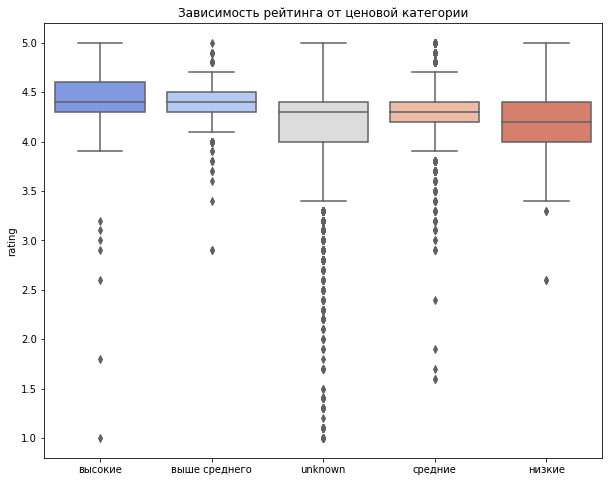

In [42]:
# Строим диаграмму размаха для рейтинга по ценовым категориям
order = median_rating['price']
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='price', y='rating', palette='coolwarm', order=order)

plt.title('Зависимость рейтинга от ценовой категории')
plt.xlabel('')
plt.show()

Мы видим, что у заведений с высокой и выше среднего ценовыми категориями медианный рейтинг и "коробка значений" немного выше. Однако мы не можем сделать вывод о том, что цена в заведении сильно влияет на его рейтинг, связь есть, но ее можно назвать слабо выраженной. 

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

В одной сети могут быть заведения разных категорий (например, у заведения может быть кафе, и еще точка где-то в ТРЦ на фудкорте) - нам нужно это учитывать при построении сводной таблицы, чтобы не потерять данные по категориям.

In [43]:
# Выделяем ТОП-15 сетей по кол-ву заведений
df_chain = df[df['chain'] == 1]
top_chains = (pd.pivot_table(df_chain, index='name', values=['id','rating'], aggfunc={'id': 'count', 'rating': 'mean'}).sort_values(by=('id'), ascending=False).head(15))
top_chains.columns = ['count_id','avg_rating']
top_chains = top_chains.reset_index()
top_chains['avg_rating'] = top_chains['avg_rating'].round(2)

print(top_chains)

                                   name  count_id  avg_rating
0                           Шоколадница       120        4.18
1                        Домино'с Пицца        76        4.17
2                            Додо Пицца        74        4.29
3                      One Price Coffee        71        4.06
4                          Яндекс Лавка        69        3.87
5                                 Cofix        65        4.08
6                                 Prime        50        4.12
7                            Хинкальная        44        4.32
8                              КОФЕПОРТ        42        4.15
9   Кулинарная лавка братьев Караваевых        39        4.39
10                              Теремок        38        4.12
11                              Чайхана        37        3.92
12                             CofeFest        32        3.98
13                              Буханка        32        4.40
14                                Му-Му        27        4.23


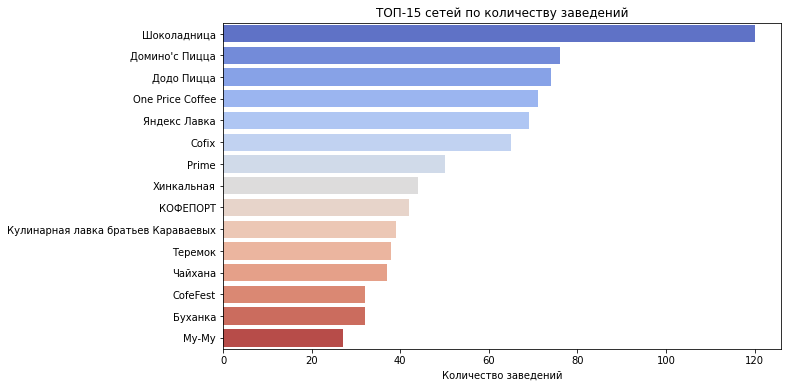

In [44]:
# Строим столбчатую диаграмму по количеству заведений в ТОП-15 популярных сетей
plt.figure(figsize=(10, 6))
sns.barplot(data=top_chains.reset_index().sort_values(by='count_id', ascending=False), y='name', x='count_id', palette='coolwarm')

plt.title('ТОП-15 сетей по количеству заведений')
plt.xlabel('Количество заведений')
plt.ylabel('')
plt.show()

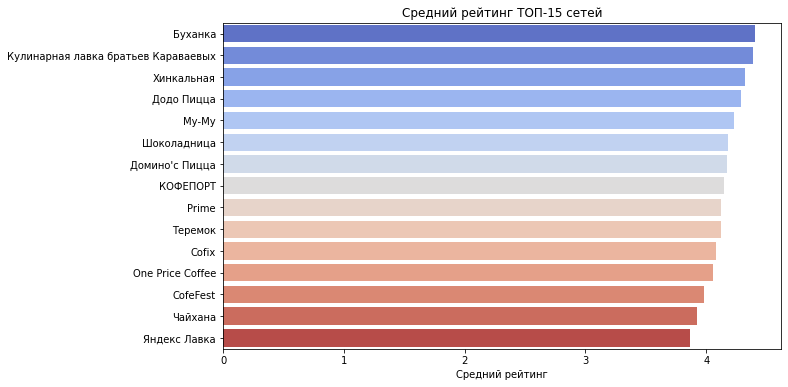

In [45]:
# Строим столбчатую диаграмму по рейтингу ТОП-15 популярных сетей
plt.figure(figsize=(10, 6))
sns.barplot(data=top_chains.reset_index().sort_values(by='avg_rating', ascending=False), y='name', x='avg_rating', palette='coolwarm')

plt.title('Средний рейтинг ТОП-15 сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('')
plt.show()

Самая популярная сеть по количеству заведений - Шоколадница (120 заведений), при этом по среднему рейтингу она занимает 6 место (4.18). Самый высокий рейтинг среди сетевых заведений - у сетей Буханка (4.4) и Кулинарная лавка братьев Караваевых (4.39). Однако у этих сетей намного меньше заведений (32 и 39 соответственно). Возможно это связано с тем, что при наличии большого количества заведений, сети сложнее выдерживать стандарты качества. Стоит выделить сети с рейтингом ниже 4 - ЯндексЛавка, Чайхана и CofeFest. 

In [46]:
# Создаем сводную таблицу с учетом того, что в одной сети могут быть заведения разных категорий
top_chains_info = pd.pivot_table(
        df_chain[df_chain['name'].isin(top_chains['name'])],
        index=['name', 'category'],
        values='rating',
        aggfunc=['count', 'mean']
    )
top_chains_info[('mean', 'rating')] = top_chains_info[('mean', 'rating')].round(2)
top_chains_info.columns = ['count', 'avg_rating']

top_chains_info


count  avg_rating
name                                category                          
CofeFest                            кафе                 1        4.20
                                    кофейня             31        3.98
Cofix                               кофейня             65        4.08
One Price Coffee                    кофейня             71        4.06
Prime                               кафе                 1        4.20
                                    ресторан            49        4.11
Буханка                             булочная            25        4.42
                                    кафе                 1        4.30
                                    кофейня              6        4.33
Додо Пицца                          пиццерия            74        4.29
Домино'с Пицца                      пиццерия            76        4.17
КОФЕПОРТ                            кофейня             42        4.15
Кулинарная лавка братьев Караваевых кафе                39        4.39
Му-Му                               бар,паб              1        4.30
                                    быстрое питание      2        4.20
                                    кафе                12        4.22
                                    кофейня              2        4.25
                                    пиццерия             1        4.30
                                    ресторан             8        4.26
                                    столовая             1        4.00
Теремок                             быстрое питание      2        4.45
                                    ресторан            36        4.11
Хинкальная                          бар,паб              3        4.33
                                    быстрое питание      6        4.37
                                    кафе                19        4.35
                                    ресторан            15        4.27
                                    столовая             1        4.20
Чайхана                             быстрое питание      2        4.30
                                    кафе                26        3.95
                                    ресторан             9        3.78
Шоколадница                         кафе                 1        4.10
                                    кофейня            119        4.18
Яндекс Лавка                        ресторан            69        3.87

In [47]:
# Посчитаем количество и долю заведений из ТОП-15 сетей по категориями
cat_top15 = (top_chains_info.groupby('category')['count'].sum().reset_index().sort_values(by='count', ascending=False))
cat_top15['share'] = round(cat_top15['count'] / cat_top15['count'].sum() * 100, 1)
cat_top15

,category,count,share
4,кофейня,336,41.2
6,ресторан,186,22.8
5,пиццерия,151,18.5
3,кафе,100,12.3
1,булочная,25,3.1
2,быстрое питание,12,1.5
0,"бар,паб",4,0.5
7,столовая,2,0.2


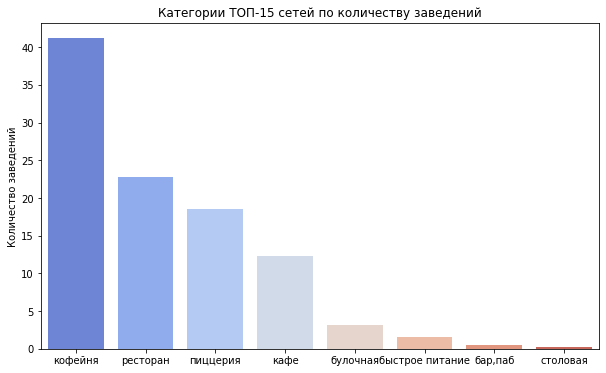

In [48]:
# Строим столбчатую диаграмму по категориям ТОП-15 популярных сетей (доля в %)
plt.figure(figsize=(10, 6))
sns.barplot(data=cat_top15.reset_index().sort_values(by='count', ascending=False), x='category', y='share', palette='coolwarm')

plt.title('Категории ТОП-15 сетей по количеству заведений')
plt.xlabel('')
plt.ylabel('Количество заведений')
plt.show()

Самой популярной категорией заведений среди ТОП-15 сетей является Кофейня (41% от всех представленных в ТОП-15 категорий). Наименее популярные категории: булочная, быстрое питание, бар/паб и столовая (менее 5% заведений приходится на каждую из них). 

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [49]:
# Посчитаем медиану среднего чека заведения по адм округам
district_bill = (df[df['middle_avg_bill'].notna()].groupby('district')['middle_avg_bill'].median().sort_values(ascending=False))
district_bill_df = district_bill.reset_index()
district_bill_df

,district,middle_avg_bill
0,Западный административный округ,1000.0
1,Центральный административный округ,1000.0
2,Северо-Западный административный округ,700.0
3,Северный административный округ,650.0
4,Юго-Западный административный округ,600.0
5,Восточный административный округ,575.0
6,Северо-Восточный административный округ,500.0
7,Южный административный округ,500.0
8,Юго-Восточный административный округ,450.0


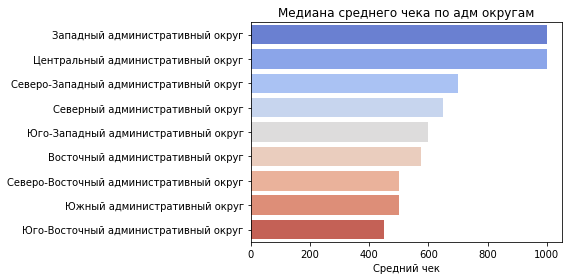

In [50]:
# Построим столбчатую диаграмму 
plt.figure(figsize=(8,4))
sns.barplot(data=district_bill_df, y='district', x='middle_avg_bill', palette='coolwarm')

plt.title('Медиана среднего чека по адм округам')
plt.xlabel('Средний чек')
plt.ylabel('')
plt.tight_layout()
plt.show()

---


Два административных округа Москвы имеют одинаково высокий медианный чек (1000): Западный и Центральный. Наименьший медианный чек у Юго-Восточного административного округа.

In [51]:
# Выведем статистические показатели столбца middle_avg_bill
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Данные явно имеют перекос и выбросы из-за очень дорогих ресторанов. Для дальнейшего анализа посчитаем границу выбросов и долю. 

In [52]:
# Посчитаем верхний порог выбросов
q1 = df['middle_avg_bill'].quantile(0.25)
q3 = df['middle_avg_bill'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
# Посчитаем долю выбросов выше верхнего порога (%)
out_upper_bound = (df['middle_avg_bill'] > upper_bound).mean() * 100

print(f'Верхний порог выбросов: {upper_bound}')
print(f'Доля данных за пределами верхнего порога: {round(out_upper_bound,2)}')

Верхний порог выбросов: 2562.5
Доля данных за пределами верхнего порога: 1.24


Чуть больше 1% значений находятся выше верхнего порога выбросов, примем их за аномальные и ограничим данные верхним порогом при построении графика распределения.

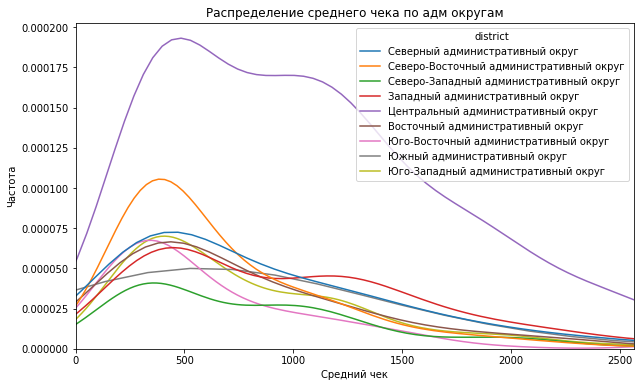

In [53]:
# Построим график и посмотрим на распределение среднего чека по административным округам (ограничив верхним порогом)
df_hist = df[df['middle_avg_bill'].notna()]
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_hist, x='middle_avg_bill', hue='district')

plt.xlim(0, upper_bound)
plt.title('Распределение среднего чека по адм округам')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
plt.show()

Кривая среднего чека ЦАО демонстрирует, что в центре Москвы сосредоточено намного больше заведений с высоким средним чеком, чем в других районах. В целом есть общая тенденция - более низких средний чек имеет большую плотность распределения, чем высокие средние чеки. 

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

В ходе исследовательского анализа можно выделить следуюзие результаты:
    
**Структура рынка по категориям**

Датасет представлен 8 категориями: 
- кафе, рестораны и кофейни (около 69%);
- бар/паб, пиццерия, быстрое питание (около 24%);
- столовые с булочными (около 7%). 

Наиболее часто среди заведений встречается категория Кафе, наименее часто - Булочная.

**Структура рынка по административным районам Москвы**

В данных представлены 9 административных округов:
- лидер по количеству заведений - Центральный адм округ (26,7% от общего количества);
- по 10-11% заведений сосредоточены в Северном, Южном, Северо-Восточном и Западном адм округах;
- менее 10% в Восточном, Юго-Восточном, Юго-Западном округах;
- наименьшая доля заведений (около 5%) - в Северо-Западном адм округе.

Отдельно мы посмотрели распределение заведений каждой категории в ЦАО. Наибольшее количество заведений (почти 30%) относятся к категории Ресторан. Катагории Кафе, Кофейня и Бар/Паб представлены 16-20% заведений в каждой из них. Остальные категории намного менее популярны в ЦАО. 

**Сетевые / несетевые зеведения**

В общем датасете с большим перевесом преобладают несетевые заведения. Их доля около 62%, что говорит о большом разнообразии заведений в Москве. Однако мы рассматрели присутствие сетевых и несетевых заведений в разрезе каждой категории. Есть 3 категории, где сетевых заведений все же больше - это Булочная, Пиццерия и Кофейня. Эти форматы проще поддаются стандартизации меню, дизайна заведения, что еще и делает процесс открытия более понятным для владельца, а также помогает быстрее привлечь первых посетителей (если это уже известная сеть). 

**Количество посадочных мест в заведениях**

В ходе исследовательского анализа былов выявлено, что данные по количеству мест вариативны и имеют выбросы. В данных присутствуют нулевые значения, что может говорить о форматах работы знекоторых заведений "на вынос". При этм так же есть и аномально высокие значения, но возможно это банкетные залы для больших мероприятий. 

Наиболее вариативными данными по количеству мест отличаются рестораны, кофейни, бары/пабы и заведения быстрого питания. Наиболее однородное распределение у столовых.

Типичное количество мест для каждой категории следующее:
- ресторан 	86 посадочных мест;
- бар,паб - 83 посадочных места;
- кофейня - 80 посадочных мест;
- столовая - 76 посадочных мест;
- быстрое питание - 65 посадочных мест;
- кафе - 60 посадочных мест;
- пиццерия - 55 посадочных мест;
- булочная - 50 посадочных мест.

**Рейтинги заведений**

Усредненные рейтинги по категориям не сильно отличаются друг от друга. Общий средний рейтинг - 4,23. Максимальный средний рейтинг у категории Бар,паб - 4,4. Минимальный - у категории Быстрое питание (4,1).

В целом, рейтинг заведения слабо зависит от других факторов, но даже средни них стоит отметить, что наибольшую связь имеют рейтинг и ценовая категория заведения. Дополнительно данная связь была рассмотрена в виде распределения рейтингов по ценовым сегментам. У заведений с высокой и выше среднего ценовыми сегментами медианный рейтинг немного выше, но различие небольшое, что подтверждает гипотезу о том, что цена не является рейтингообразующим фактором. В низком ценовом сегменте данные о рейтинге наиболее вариативны, но, также, не имеют сильно выраженных отличий от других категорий. 

**ТОП-15 популярных сетей**

В ТОП-15 сетей по количеству заведений входят следующие сети (перечислены по убыванию кол-ва заведений): Шоколадница, Домино'с Пицца, Додо Пицца, One Price Coffee, Яндекс Лавка, Cofix,  Prime, Хинкальная, КОФЕПОРТ,        Кулинарная лавка братьев Караваевых, Теремок, Чайхана, CofeFest, Буханка, Му-Му. 

Самая популярная сеть по количеству заведений - Шоколадница (120 заведений), при этом по среднему рейтингу она занимает 6 место (4.18). Самый высокий рейтинг среди сетевых заведений - у сетей Буханка (4.4) и Кулинарная лавка братьев Караваевых (4.39). Однако у этих сетей намного меньше заведений (32 и 39 соответственно). У всех сетей средний рейтинг близок к 4 и не имеет сильных различий (сети с рейтингом немного ниже 4 - ЯндексЛавка, Чайхана и CofeFest).

Некоторые сети представлены заведениями в нескольких категориях, это: CofeFest, Prime, Буханка, Му-Му, Теремок, Хинкальная, Чайхана и Шоколадница. При этом самой многочисленной категорией среди ТОП-15 сетей является Кофейня (41% заведений), а наменьшими по численности - Бар,Паб и Столовая (менее 1%).

**Средний чек заведений в разрезе адм округов**

В данных о среднем чеке замечены выбросы (очень высокие средние чеки), однако таких заведений всего 1,24%. Остальные показатели находятся в пределах верхнего выброса (около 2600 руб), при этом половина заведений имеют средний чек в пределах 750 руб. 

В ЦАО наблюдается присутствие большего количество заведений с высоким средним чеком, чем в других районах, что скорее всего обсуловлено более выгодным расположениеv заведений и активностью района в целом (центр города). В остальных районах средний чек сильнее смещен в сторону меньшей суммы, но при этом кривые распределния имеют "хвост" дорогих чеков. Наиболее вариативные данные в Северо-Восточном адм округе.

В целом, можно сделать вывод, что зависимость среднего чека от адм района слабая. Есть яркая зависимость от ЦАО: в центре города заведения дороже, чем в других районах. 


## 4. Итоговый вывод и рекомендации

В рамках проекта было проведено исследование данных о рынке общественного питания Москвы. Использовались данные, составлены на омнове информации из Яндекс Карты и Яндекс Бизнес на лето 2022 года.
В ходе анализа были рассмотрены категории заведений, административные районы, присутствие на рынке сетевых и несетевых заведений, количество посадочных мест, рейтинг заведений по категориями, корреляция рейтинга заведений, составлен ТОП-15 сетей, а также изкчена зависимость среднего чека от адм округа, в котором находится заведение. 

*Можно отметить следующие ключевые моменты:*
- в данных представлены восемь категорий заведений, среди которых наиболее популярными являются Кафе, Кофейни и Рестораны, а наименее популярными - Столовые и Булочные;
- в Центральном административном округе наблюдается более высокая конкуренция среди заведений (это самый многочисленный по заведениям округ), при этом больше всего здесь представлены Рестораны. Меньше всего заведений - в Северо-Западном админстративном округе; 
- в разрезе принадлежности заведений к сети, наблюдается большой перевес в пользу несетевые заведений, что говорит о разнообразии и уникальности концепций. В 3 категориях (Булочные, Пиццерии и Кофейни) заведения чаще относятся к сети;
- данные о количестве мест для посадки гостей вариативны. Во всех категориях есть заведения с маленьким и большим количеством посадочных мест. Среднее число посадочных мест по всем категориям находится в диапозоне 50-86. Однако можно выделить, что самыми большими являются Рестораны, Бары/Пабы и Кофейни. В этих категориях и категории Быстрое питание данные разбросаны сильнее, что говорит о разнообразии форматов (есть как небольшие, например, семейные ресторанчики или корнеры быстрого питания, так и большие, например, банкетные залы и фудкорты).
- для пользователей категория заведения не является основным фактором при его оценке - cредние рейтинги заведений разных категорий не сильно различаются между собой и все находятся в районе оценки 4. Минимальный средний рейтинг у категории быстрого питания (4,05), а максимальный - у категории бар/паб (4,39);
- рейтинг является все же субъективной оценкой пользователей и слабо зависит от других параметров заведений. Однако все же у заведений высокого и выше среднего ценовых сегментов медианный рейтинг немного выше. Скорее всего это связано с тем, что дорогие заведения более тщательно следят за стандартами качества и уровнем сервиса;
- cамая популярная сеть по количеству заведений - Шоколадница (120 заведений), далее Домино'с Пицца, Додо Пицца,   One Price Coffee, Яндекс Лавка, Cofix (по 65-76 заведений), каждая из остальных ТОП-15 сетей имеет не более 50 заведений. Некоторые сети представлены в разных категориях (например, могут иметь и точку быстрого питания, и кофейню), но самой популярной категорией для сетей является Кофейня;
- заведения, расположенные в центре города (а именно в Центральном адм округе) имеют более всокий средний чек по отношению к другим адм округам. При этом тенденция в остальных адм округах одинаковая: большинство заведений находятся в более низком диапозоне среднего чека, но данные имеют длинный "хвост" высоких значений, что говорит о том, что дорогие и дешевые заведения присутствуют во всех адм округах Москвы. 

*Основываясь на полученной информации о рынке общественного питания Москвы, можно учесть следующие рекомендации:*

Кофейни являются популярными, однако открывая заведение данной категории нужно быть готовыми к высокой конкуренции, в том числе с сетевыми кофейнями - обычно новым точкам сетей проще привлечь гостей, за счет того, что название заведения уже знакомо людям. Кафе, рестораны и бары/пабы тоже предполагают высокую конкуренцию, однако здесь присутствует меньше представителей сетей, поэтому при открытии такого заведения стоит делать акцент на уникальную концепцию, интересный интертер и авторское меню. 

По размеру зала следует ориентироваться на диапозон 50-85 посадочных мест, что является типичным для заведений. Но при выборе в пользу Ресторана или Бара/Паба стоит приближаться к верхней границе (что типично именно для этих категорий в силу того, что формат предполагает более длительное нахождение гостей в заведении: ужин, встреча с друзьями, проведение мероприятий и тд).

Заведение любой категории преполагает более высокий средний чек, если оно будет расположено в ЦАО - да, это более активный район, но насыщенность рынка в нем и более высокие цены преполагают особый контроль за качеством и сервисом. При выборе другого района все же стоит обратить внимание на средний ценовой сегмент, чтобы не проигрывать в конкуренции с другими заведениями из-за высокой цены. 

При этом категория и район не особо влияют на рейтинг заведения - нужно учитывать то, что скорее всего гости больше оценивают качество (например уровень сервиса, чистота, атмосфера, кухня и интересное меню). 